1. To run the venv of the project:

source .venv/bin/activate

In [1]:
# change 20260309 sdfd
import sys
print(sys.executable)

/home/datvt/Documents/projects/mta/ky2t5_deeplearning/python-data-demo/.venv/bin/python


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
# thư viện dùng để chuẩn hóa dữ liệu (feature scaling)
from sklearn.preprocessing import StandardScaler
# xử lý dữ liệu mất cân bằng (imbalanced dataset) bằng cách tăng số lượng mẫu của lớp thiểu số (minority class).
from imblearn.over_sampling import RandomOverSampler

### Dataset:
Dua, D. and Graff, C. (2019). UCI Machine Learning Repository [http://archive.ics.uci.edu/ml]. Irvine, CA: University of California, School of Information and Computer Science.

Donated by:
P. Savicky
Institute of Computer Science, AS of CR
Czech Republic
savicky '@' cs.cas.cz

In [3]:
cols = ["fLength", "fWidth", "fSize", "fConc", "fConc1", "fAsym", "fM3Long", "fM3Trans", "fAlpha", "fDist", "class"]
df = pd.read_csv("/home/datvt/Documents/projects/mta/ky2t5_deeplearning/python-data-demo/notebooks/tut/data/magic+gamma+telescope/magic04.data", 
                 names=cols)
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [4]:
df["class"].value_counts()[["g", "h"]]

class
g    12332
h     6688
Name: count, dtype: int64

In [5]:
df["class"] = (df["class"] == "g").astype(int)

In [6]:
df["class"].value_counts()[[1, 0]]

class
1    12332
0     6688
Name: count, dtype: int64

In [7]:
# 10 cols đầu là features và 1 col cuối cùng là class label
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,1
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,1
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,1
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,1
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,1


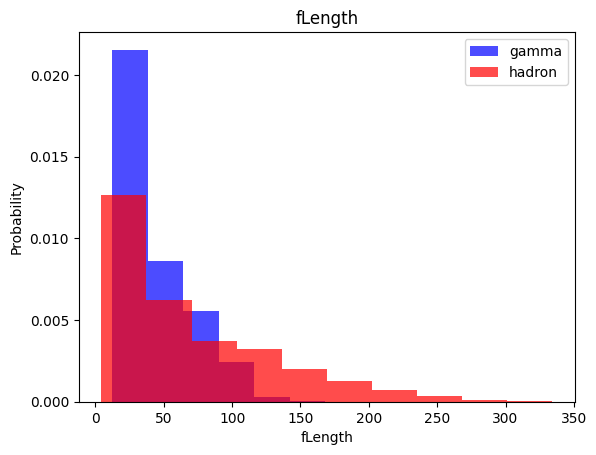

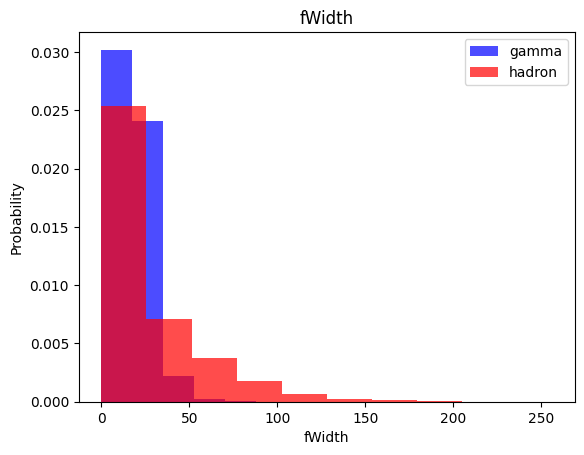

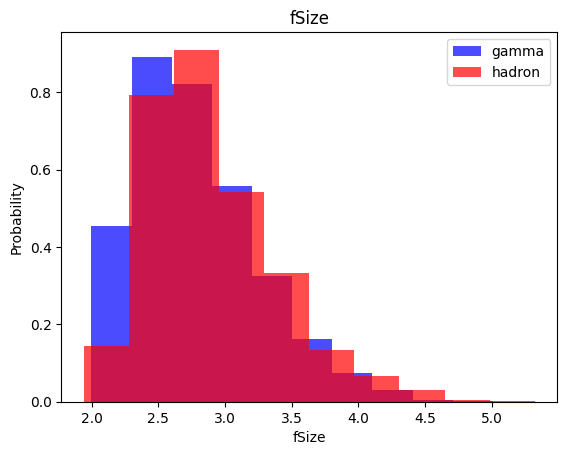

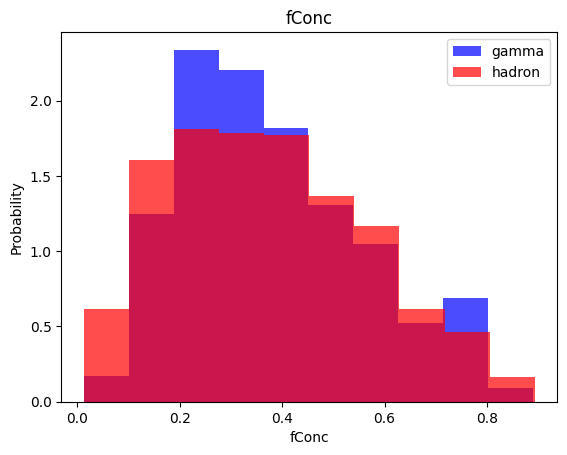

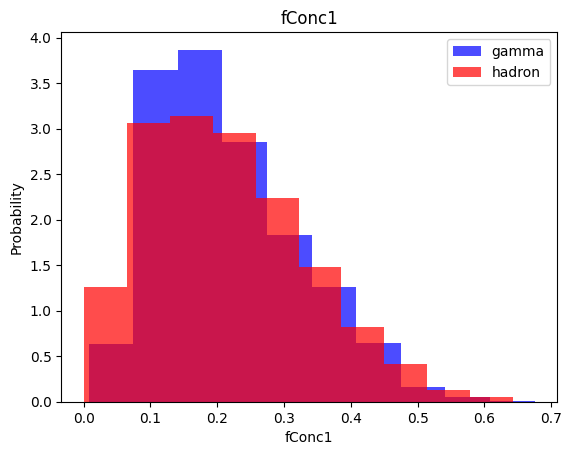

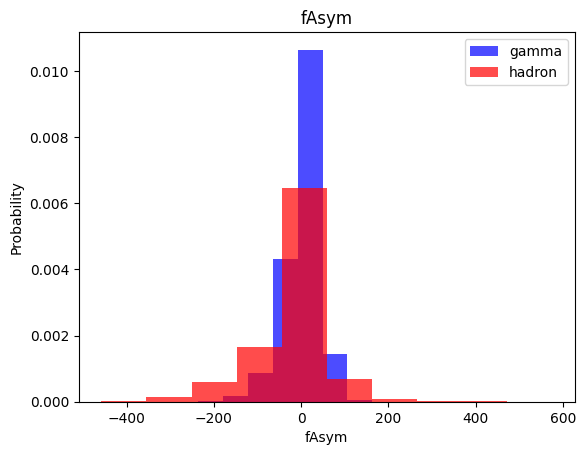

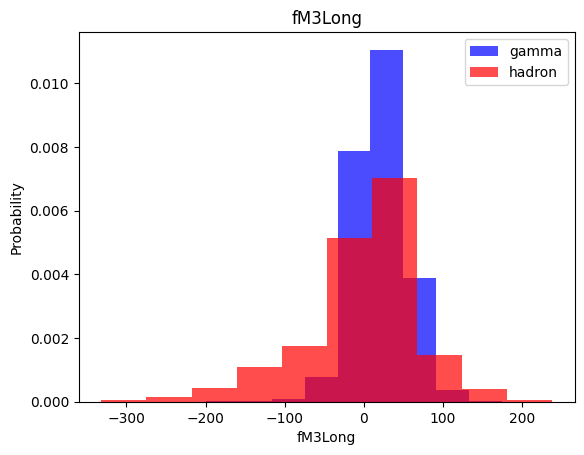

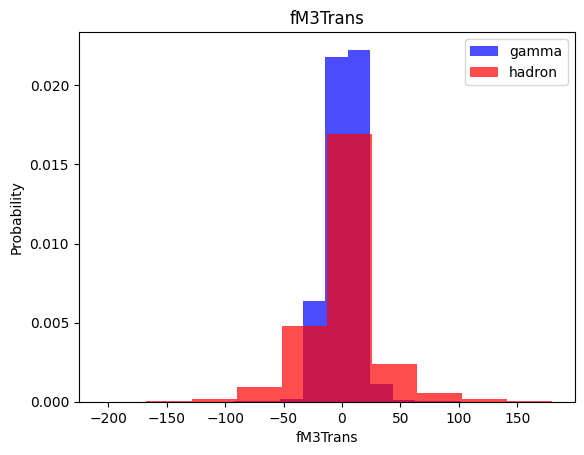

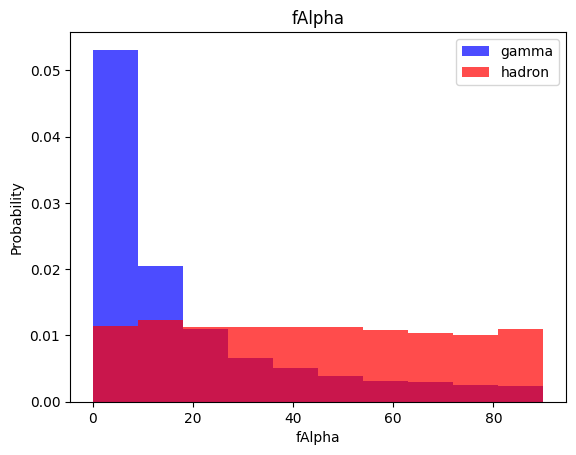

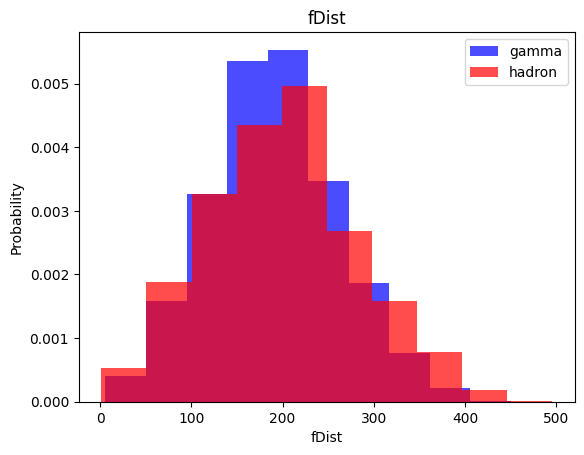

In [8]:
# Lặp qua tất cả các phần tử trong cols, trừ phần tử cuối cùng.
for label in cols[:-1]:
    # if label != 'fLength':
    #     continue
    # Vẽ biểu đồ histogram cho các giá trị của cột label, nhưng chỉ lấy những dòng có class = 1
    plt.hist(df[df['class']==1][label], color='blue', label='gamma', alpha=0.7, density=True)
    # Vẽ biểu đồ histogram cho các giá trị của cột label, nhưng chỉ lấy những dòng có class = 0
    plt.hist(df[df['class']==0][label], color='red', label='hadron', alpha=0.7, density=True)
    plt.title(label)
    plt.ylabel("Probability")
    plt.xlabel(label)
    # show chú thích label (gamma/hadron) trên đồ thị
    plt.legend()
    # Hiển thị biểu đồ ra màn hình
    plt.show()

### Train, validation, test datasets

In [9]:
# được dùng để shuffle và chia dataset thành 3 phần: train / validation / test
# - df.sample(frac=1):
#  + frac=1 nghĩa là lấy 100% dữ liệu
#  + sample() mặc định sẽ xáo trộn (shuffle) thứ tự các dòng
# - Tỷ lệ cuối cùng: 60/20/20
#  + train: 0-60%
#  + valid: 60-80%
#  + test: 80-100%
# train, valid, test = np.split(df.sample(frac=1), [int(0.6*len(df)), int(0.8*len(df))])

df_shuffled = df.sample(frac=1)
df_train = df_shuffled.iloc[:int(0.6*len(df))]
df_valid = df_shuffled.iloc[int(0.6*len(df)):int(0.8*len(df))]
df_test  = df_shuffled.iloc[int(0.8*len(df)):]


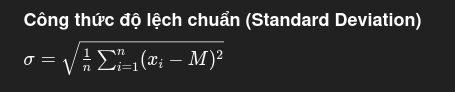


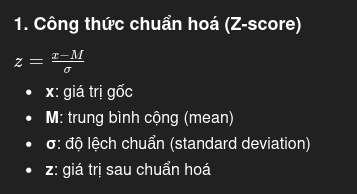



In [10]:
def scale_dataset(dataframe, oversample=False):
    # dataframe.columns[:-1] -> Cú pháp slice trong Python
    # lấy từ đầu đến trước phần tử cuối
    # Ví dụ:
    #  ['age', 'height', 'weight', 'label'][:-1]
    # Kết quả:
    #  ['age', 'height', 'weight']
    # => dataframe[dataframe.columns[:-1]] sẽ lấy tất cả các cột, trừ cột cuối
    # Lấy tất cả các cột để  làm dữ liệu đầu vào X
    X = dataframe[dataframe.columns[:-1]].values
    # lấy cột cuối cùng làm label y
    y = dataframe[dataframe.columns[-1]].values
    
    # chuẩn hoá dữ liệu ->
    # 1. tính trung bình cộng μ (muy)
    # 2. tính độ lệch chuẩn σ (sigma)
    # -> chuẩn hoá x = (x - μ) / σ
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    # có những trường hợp khi tập dataset bị mất cân bằng
    # sử dụng thư viện này nhằm tăng só lượng samples cho class có ít samples hơn
    if oversample:
        ros = RandomOverSampler()
        X, y = ros.fit_resample(X, y)
    
    # - np.hstack: xếp các dòng tương ứng của X với y theo chiều ngang
    # ví dụ:
    # X        y
    # 1  10    0
    # 2  20    1
    # 3  30    0
    # - do X là dữ liệu 2 chiều, y là dữ liệu 1 chiều -> không thể ghép nối
    # X.size() = [n1, n2]
    data = np.hstack((X, np.reshape(y, (-1,1))))
    
    return data, X, y

In [11]:
# thường thì ta chỉ cần over sample cho tập training dataset
# do đối với tập valid và test, ta coi như là các dữ liệu chưa biết đến nên hoàn toàn có thể  bị lệch
# (dữ liệu phân phối không đều giữa các class)
train, X_train, y_train = scale_dataset(df_train, True)
valid, X_valid, y_valid = scale_dataset(df_valid, False)
test, X_test, y_test = scale_dataset(df_test, False)

In [12]:
len(y_train)

14788

In [13]:
#gamma =  tín hiệu
#hadron = background
print('y_train == 1: ', sum(y_train == 1))
print('y_train == 0: ', sum(y_train == 0))
print('y_valid == 1: ', sum(y_valid == 1))
print('y_valid == 0: ', sum(y_valid == 0))
# sau khi thực hiện RandomOverSampler -> số  lượng mẫu cho các labels đã được cân bằng

y_train == 1:  7394
y_train == 0:  7394
y_valid == 1:  2512
y_valid == 0:  1292


# 1. kNN

In [14]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

In [15]:
knn_model = KNeighborsClassifier(n_neighbors=1)
knn_model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [16]:
y_pred = knn_model.predict(X_test)

1. Các cột (precision, recall, f1-score, support)  
- precision (độ chính xác)  
Tỷ lệ dự đoán đúng trong số các mẫu được mô hình dự đoán là lớp đó.  
Công thức:

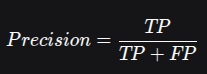

- recall (độ nhạy / tỷ lệ phát hiện đúng)  
Tỷ lệ mô hình dự đoán đúng trong số các mẫu thực tế thuộc lớp đó.  
Công thức:  

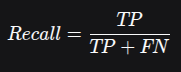

- f1-score:  
Trung bình điều hòa của precision và recall  

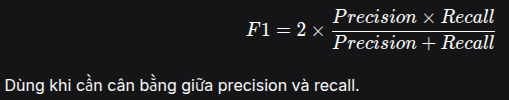

- support:  
Số  lượng mẫu thực tế thuộc lớp đó trong tập kiểm tra (hoặc validation)  
ví dụ: 1343 mẫu thuộc lớp 0, 2461 mẫu thuộc lớp 1  

- lớp 0: nhãn không có bệnh  
- lớp 1: nhãn có bệnh  

- Dòng accuracy (độ chính xác tổng thể)  
- Dòng macro avg (trung bình không trọng số):
Lấy trung bình cộng theo cột tương ứng

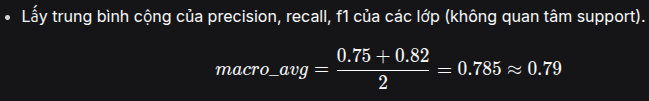

- Dòng weighted avg (trung bình có trọng số):  
Lấy trung bình theo support của từng lớp

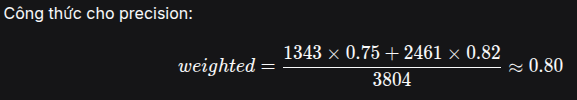

In [17]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.69      0.74      1378
           1       0.84      0.89      0.86      2426

    accuracy                           0.82      3804
   macro avg       0.81      0.79      0.80      3804
weighted avg       0.82      0.82      0.82      3804



# 2. Naive Bayes

In [18]:
from sklearn.naive_bayes import GaussianNB

In [19]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [20]:
y_pred = nb_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.41      0.53      1378
           1       0.73      0.91      0.81      2426

    accuracy                           0.73      3804
   macro avg       0.73      0.66      0.67      3804
weighted avg       0.73      0.73      0.71      3804



# 3. Logistic regression

In [21]:
from sklearn.linear_model import LogisticRegression

In [22]:
lg_model = LogisticRegression()
lg_model = lg_model.fit(X_train, y_train)

In [23]:
y_pred = lg_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.73      0.72      1378
           1       0.84      0.83      0.84      2426

    accuracy                           0.80      3804
   macro avg       0.78      0.78      0.78      3804
weighted avg       0.80      0.80      0.80      3804



# 4. SVM

In [24]:
from sklearn.svm import SVC

In [25]:
svm_model = SVC()
svm_model = svm_model.fit(X_train, y_train)

In [26]:
y_pred = svm_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.81      0.81      1378
           1       0.89      0.89      0.89      2426

    accuracy                           0.86      3804
   macro avg       0.85      0.85      0.85      3804
weighted avg       0.86      0.86      0.86      3804



# 5. Neural network NN

In [27]:
import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))

I0000 00:00:1778169562.664912   11128 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778169563.360636   11128 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778169564.712461   11128 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


[]


W0000 00:00:1778169565.095746   11128 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [28]:
# TODO: remove

# history là object trả về từ model.fit(...) trong keras
# history chứa toàn bộ log quá trình train. ví dụ: loss, val_loss theo từng epoch
# history.history là 1 dictionary
# 'loss' là loss trên training set theo từng epoch
# 'val_loss' là loss trên validation set theo từng epoch -> vẽ để so sánh với loss
def plot_loss(history):
  plt.plot(history.history['loss'], label='loss') # training loss
  plt.plot(history.history['val_loss'], label='val_loss') # validation loss
  plt.xlabel('Epoch')
  plt.ylabel('Binary crossentropy')
  plt.legend()
  plt.grid(True)
  plt.show()

# accuracy = training accuracy
# val_accuracy = validation accuracy
def plot_accuracy(history):
  plt.plot(history.history['accuracy'], label='accuracy')
  plt.plot(history.history['val_accuracy'], label='val_accuracy')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.legend()
  plt.grid(True)
  plt.show()

In [29]:
def plot_history(history):
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

  ax1.plot(history.history['loss'], label='loss') # training loss
  ax1.plot(history.history['val_loss'], label='val_loss') # validation loss
  ax1.set_xlabel('Epoch')
  ax1.set_ylabel('Binary crossentropy')
  ax1.grid(True)

  ax2.plot(history.history['accuracy'], label='accuracy')
  ax2.plot(history.history['val_accuracy'], label='val_accuracy')
  ax2.set_xlabel('Epoch')
  ax2.set_ylabel('Accuracy')
  ax2.grid(True)

  plt.show()

In [ ]:

# dropout layer: theo 1 tỷ lệ nhất định -> tránh việc overfit
def train_model(X_train, y_train, num_nodes, dropout_prob, lr, batch_size, epochs):
    nn_model = tf.keras.Sequential([
        tf.keras.layers.Dense(num_nodes, activation='relu', input_shape=(10,)),
        tf.keras.layers.Dropout(dropout_prob),
        tf.keras.layers.Dense(num_nodes, activation='relu'),
        tf.keras.layers.Dropout(dropout_prob),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ]   )

    # do model compile with loss và độ đo metrics
    # ===> model.evaluate(...) return: [loss, accuracy]
    # do khi compile model theo thứ tự loss và metrics accuracy -> return loss trước
    nn_model.compile(optimizer=tf.keras.optimizers.Adam(lr),
                    loss='binary_crossentropy',
                    metrics=['accuracy'])

    # verbose=0 -> not print anything while training
    history = nn_model.fit(
        X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2, verbose=0
        # ta có thể làm như sau
        # tạo tập validation data và truyền vào, thay vì split random như thế  này
        # X_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=validation_data, verbose=0
    )

    return nn_model, history

------------------------------------------------------------------------------------------
16 node, 0 dropout_prob, 0.1 lr, 32 batch_size


/home/datvt/Documents/projects/mta/ky2t5_deeplearning/python-data-demo/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


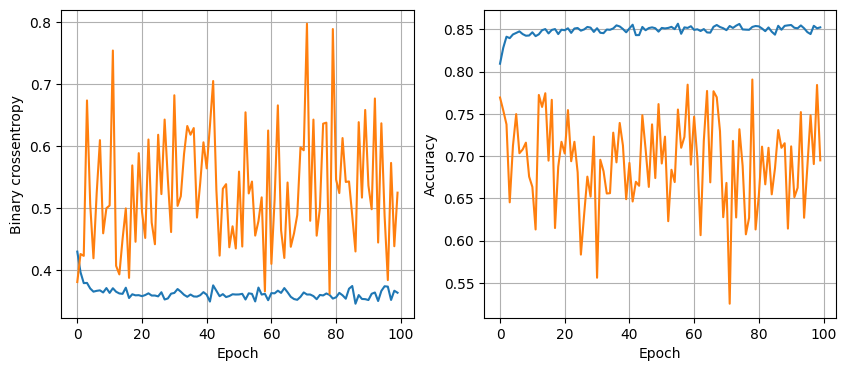

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 540us/step - accuracy: 0.8612 - loss: 0.3479
------------------------------------------------------------------------------------------
16 node, 0 dropout_prob, 0.1 lr, 64 batch_size


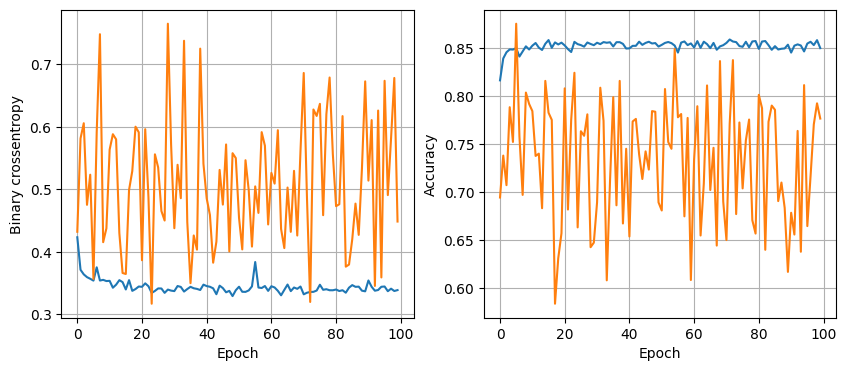

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 598us/step - accuracy: 0.8565 - loss: 0.3599
------------------------------------------------------------------------------------------
16 node, 0 dropout_prob, 0.1 lr, 128 batch_size


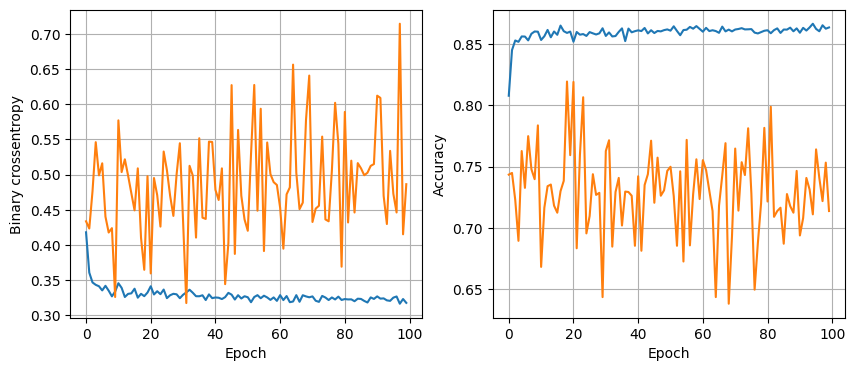

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 520us/step - accuracy: 0.8649 - loss: 0.3248
------------------------------------------------------------------------------------------
16 node, 0 dropout_prob, 0.005 lr, 32 batch_size


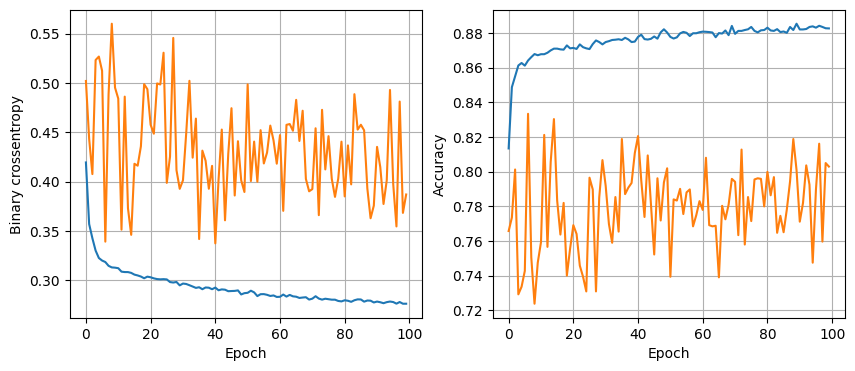

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 557us/step - accuracy: 0.8715 - loss: 0.3158
------------------------------------------------------------------------------------------
16 node, 0 dropout_prob, 0.005 lr, 64 batch_size


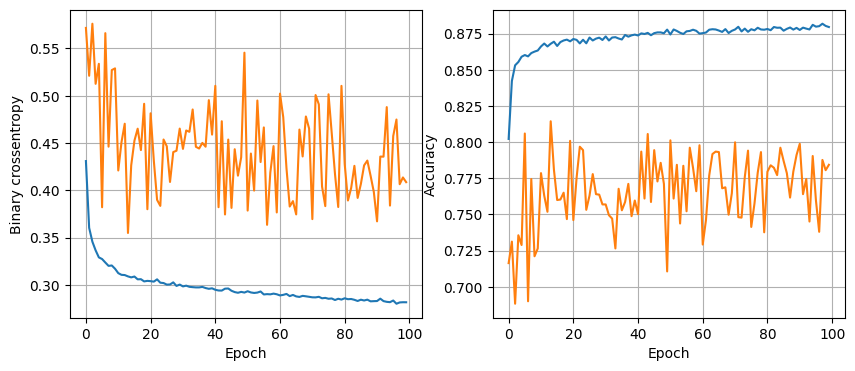

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 515us/step - accuracy: 0.8741 - loss: 0.3137
------------------------------------------------------------------------------------------
16 node, 0 dropout_prob, 0.005 lr, 128 batch_size


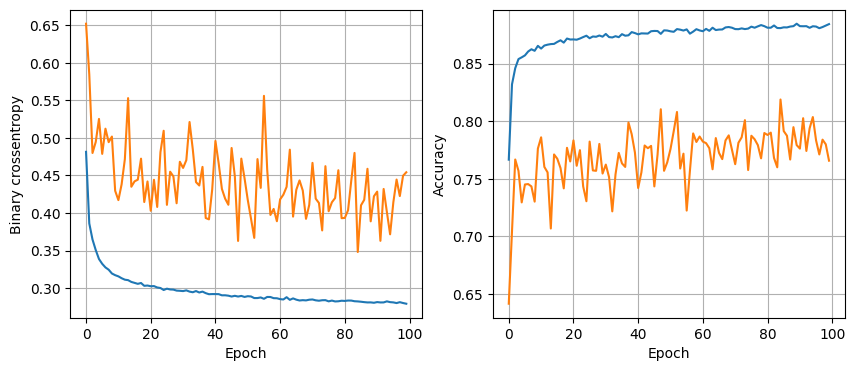

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 616us/step - accuracy: 0.8707 - loss: 0.3120
------------------------------------------------------------------------------------------
16 node, 0 dropout_prob, 0.001 lr, 32 batch_size


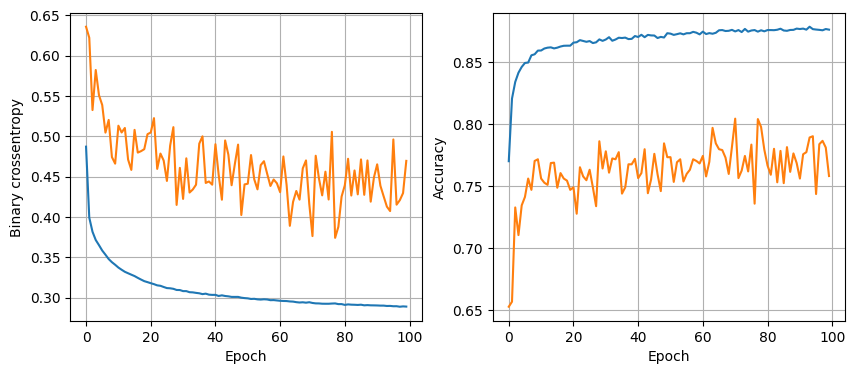

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 790us/step - accuracy: 0.8683 - loss: 0.3159
------------------------------------------------------------------------------------------
16 node, 0 dropout_prob, 0.001 lr, 64 batch_size


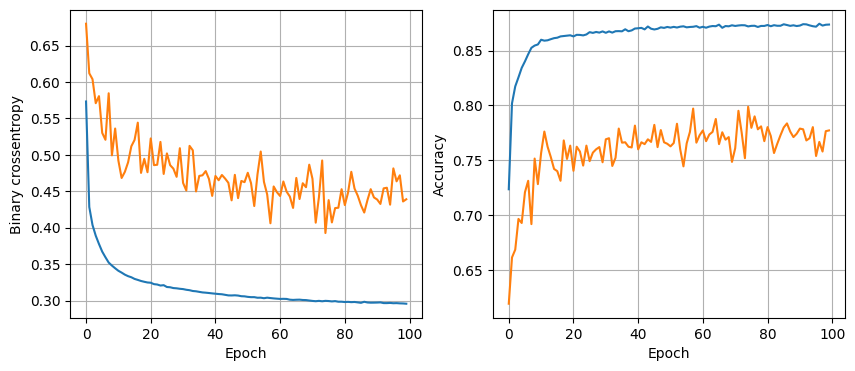

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 498us/step - accuracy: 0.8662 - loss: 0.3143
------------------------------------------------------------------------------------------
16 node, 0 dropout_prob, 0.001 lr, 128 batch_size


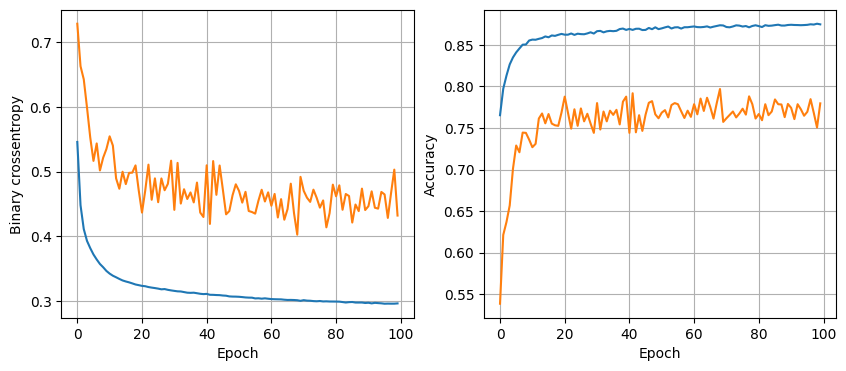

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 775us/step - accuracy: 0.8693 - loss: 0.3144
------------------------------------------------------------------------------------------
16 node, 0.2 dropout_prob, 0.1 lr, 32 batch_size


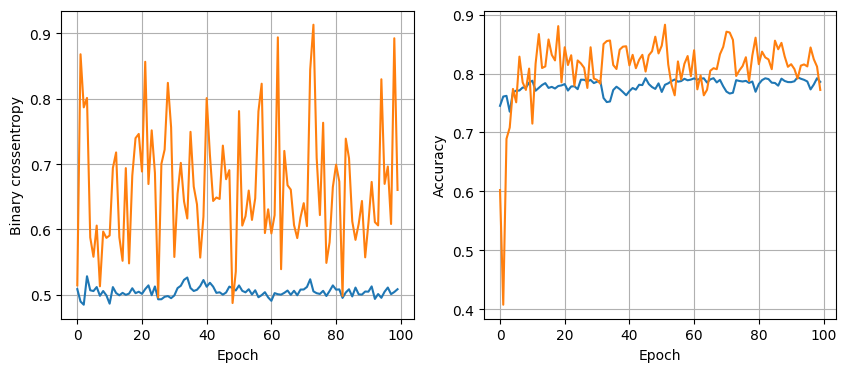

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 506us/step - accuracy: 0.8102 - loss: 0.4514
------------------------------------------------------------------------------------------
16 node, 0.2 dropout_prob, 0.1 lr, 64 batch_size


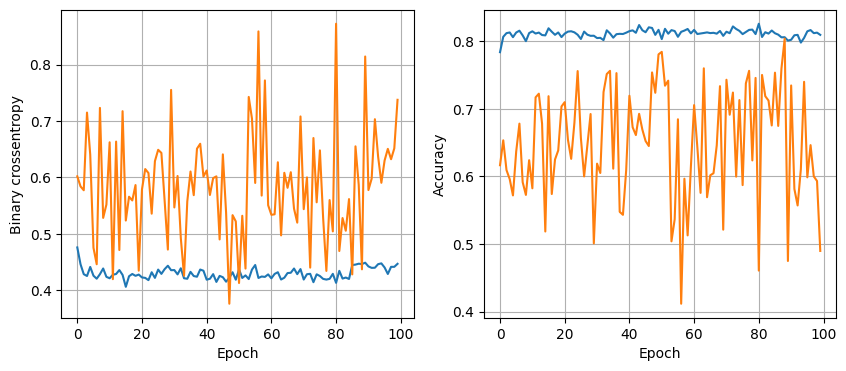

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 605us/step - accuracy: 0.8168 - loss: 0.4241
------------------------------------------------------------------------------------------
16 node, 0.2 dropout_prob, 0.1 lr, 128 batch_size


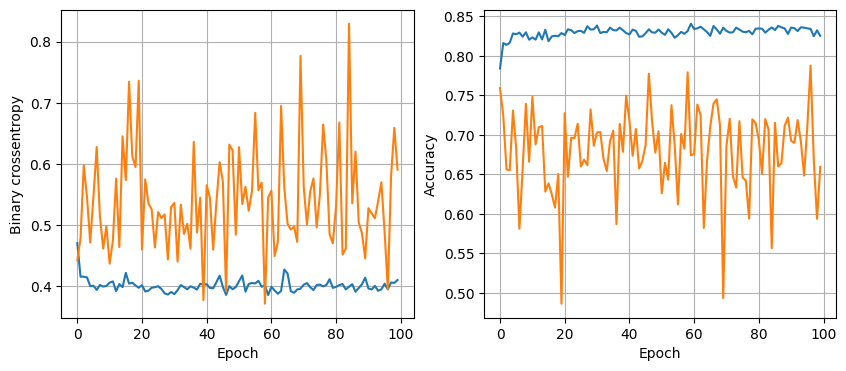

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 529us/step - accuracy: 0.8528 - loss: 0.3488
------------------------------------------------------------------------------------------
16 node, 0.2 dropout_prob, 0.005 lr, 32 batch_size


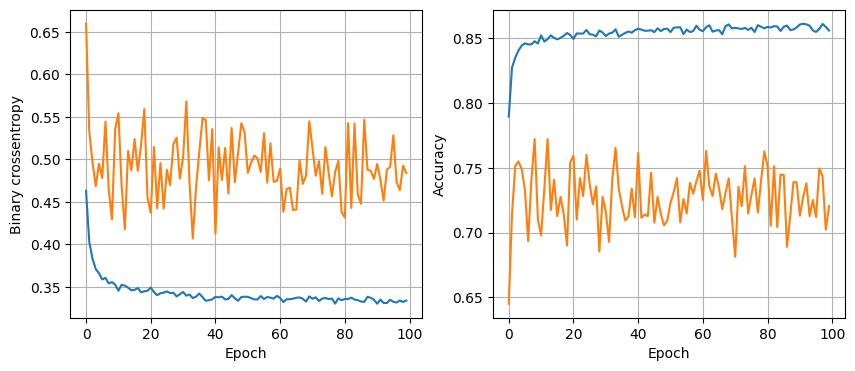

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 584us/step - accuracy: 0.8712 - loss: 0.3162
------------------------------------------------------------------------------------------
16 node, 0.2 dropout_prob, 0.005 lr, 64 batch_size


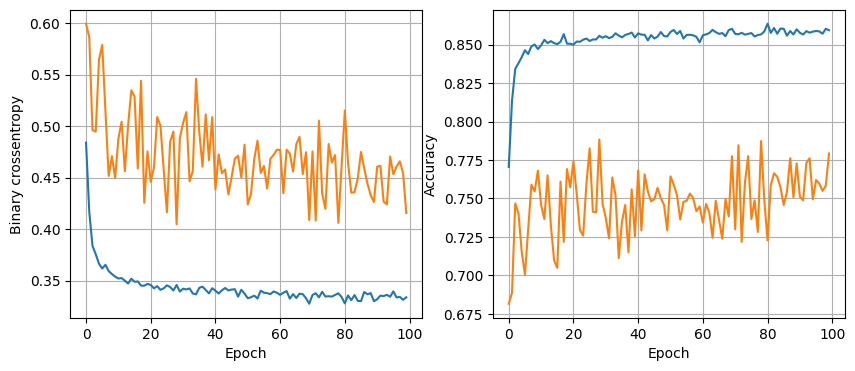

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 530us/step - accuracy: 0.8646 - loss: 0.3204
------------------------------------------------------------------------------------------
16 node, 0.2 dropout_prob, 0.005 lr, 128 batch_size


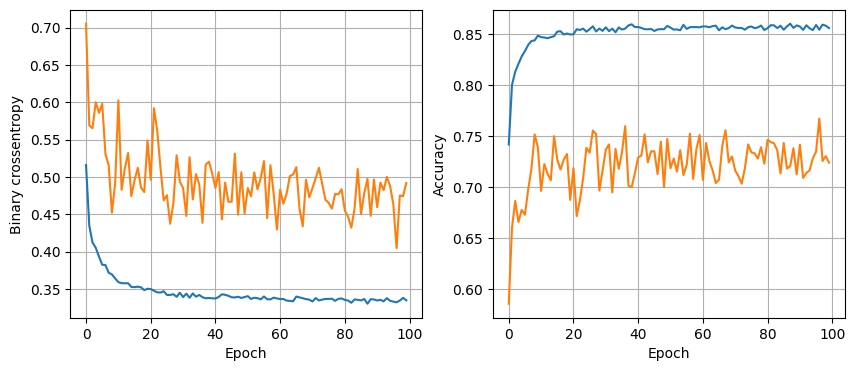

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 560us/step - accuracy: 0.8657 - loss: 0.3228
------------------------------------------------------------------------------------------
16 node, 0.2 dropout_prob, 0.001 lr, 32 batch_size


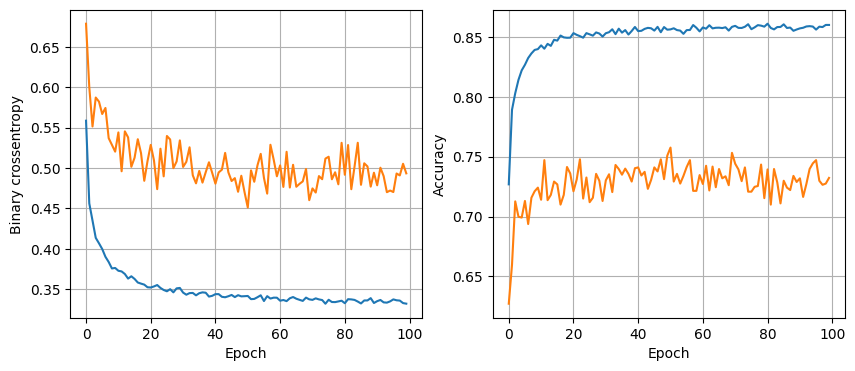

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 561us/step - accuracy: 0.8657 - loss: 0.3225
------------------------------------------------------------------------------------------
16 node, 0.2 dropout_prob, 0.001 lr, 64 batch_size


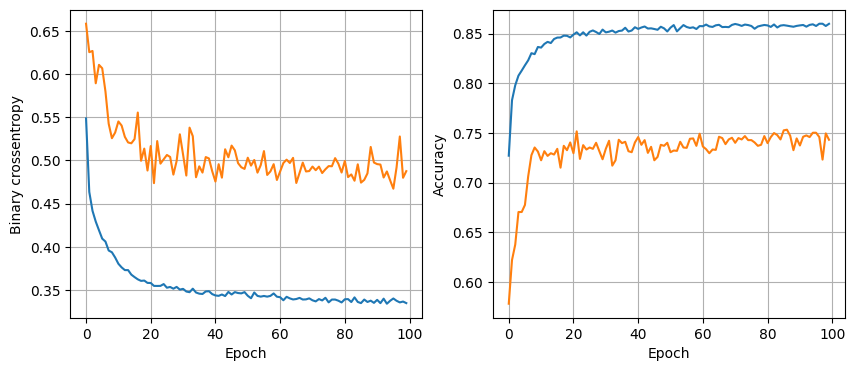

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 534us/step - accuracy: 0.8675 - loss: 0.3224
------------------------------------------------------------------------------------------
16 node, 0.2 dropout_prob, 0.001 lr, 128 batch_size


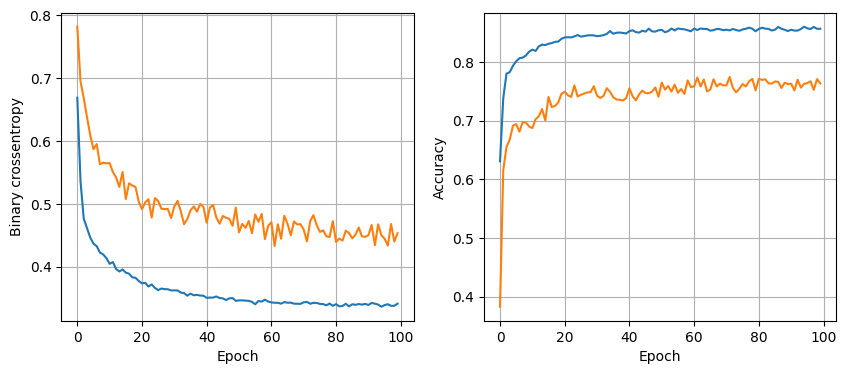

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 557us/step - accuracy: 0.8641 - loss: 0.3236
------------------------------------------------------------------------------------------
32 node, 0 dropout_prob, 0.1 lr, 32 batch_size


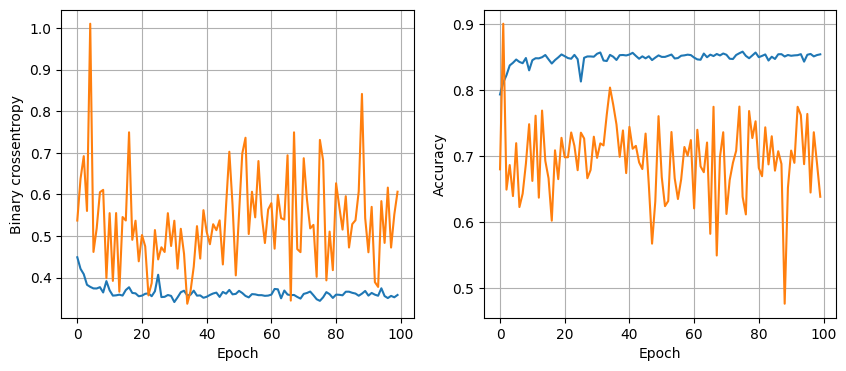

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 836us/step - accuracy: 0.8517 - loss: 0.3531
------------------------------------------------------------------------------------------
32 node, 0 dropout_prob, 0.1 lr, 64 batch_size


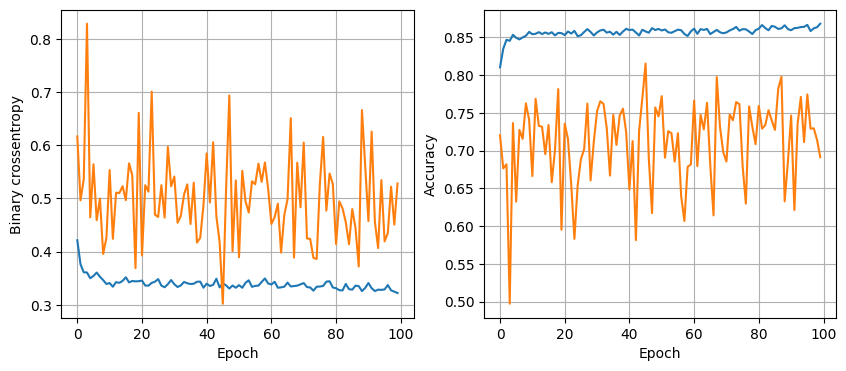

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 558us/step - accuracy: 0.8638 - loss: 0.3306
------------------------------------------------------------------------------------------
32 node, 0 dropout_prob, 0.1 lr, 128 batch_size


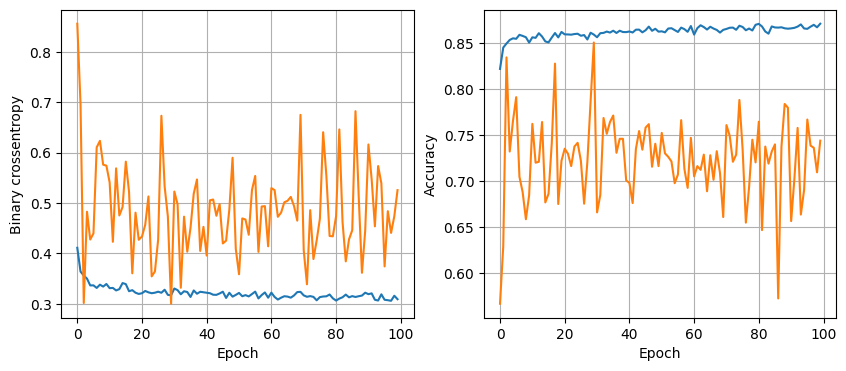

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 591us/step - accuracy: 0.8712 - loss: 0.3396
------------------------------------------------------------------------------------------
32 node, 0 dropout_prob, 0.005 lr, 32 batch_size


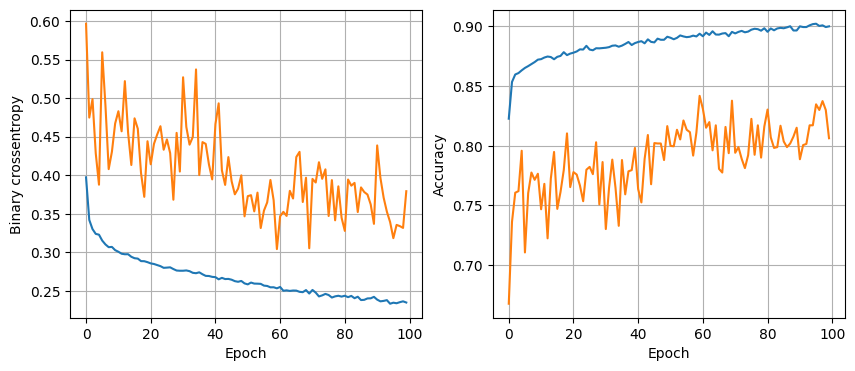

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 610us/step - accuracy: 0.8644 - loss: 0.3736
------------------------------------------------------------------------------------------
32 node, 0 dropout_prob, 0.005 lr, 64 batch_size


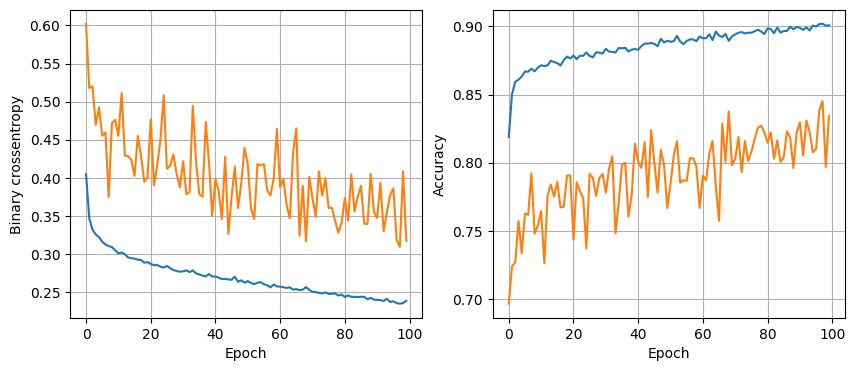

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 541us/step - accuracy: 0.8670 - loss: 0.3562
------------------------------------------------------------------------------------------
32 node, 0 dropout_prob, 0.005 lr, 128 batch_size


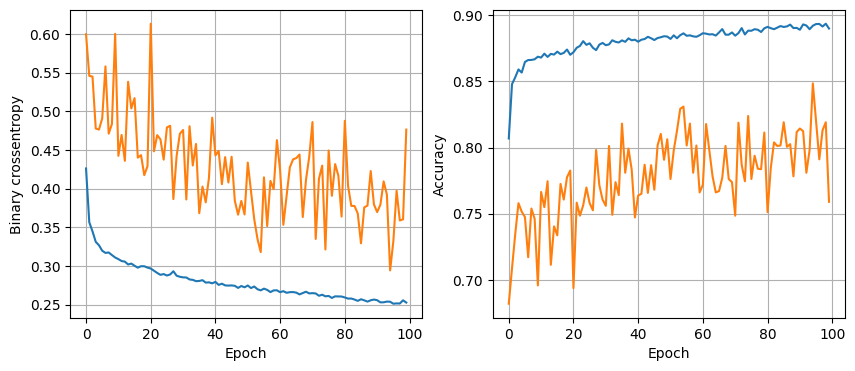

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 695us/step - accuracy: 0.8699 - loss: 0.3432
------------------------------------------------------------------------------------------
32 node, 0 dropout_prob, 0.001 lr, 32 batch_size


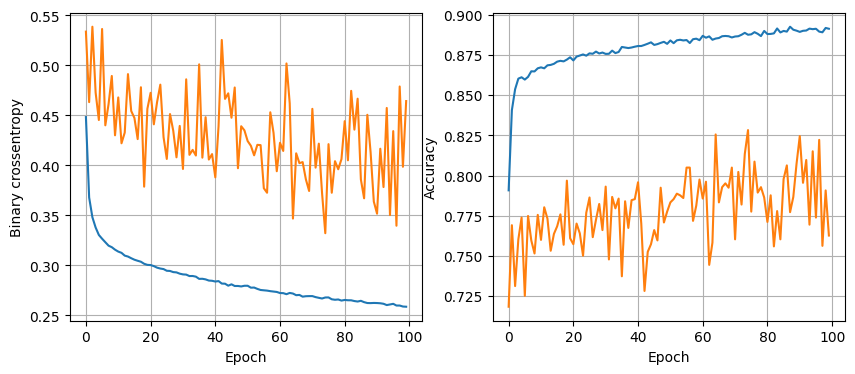

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 544us/step - accuracy: 0.8733 - loss: 0.3246
------------------------------------------------------------------------------------------
32 node, 0 dropout_prob, 0.001 lr, 64 batch_size


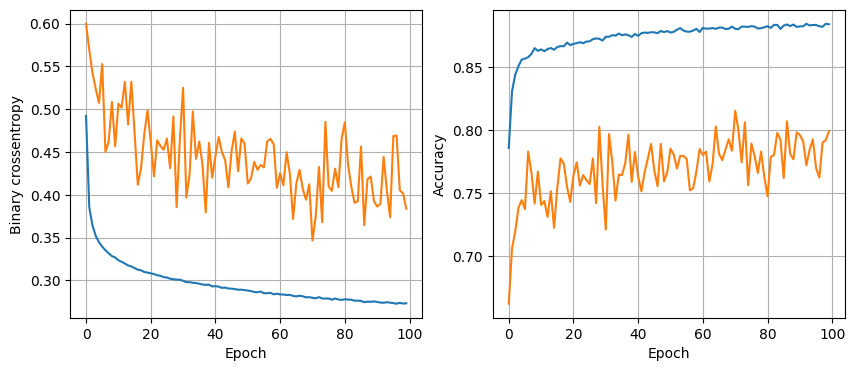

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 638us/step - accuracy: 0.8693 - loss: 0.3107
------------------------------------------------------------------------------------------
32 node, 0 dropout_prob, 0.001 lr, 128 batch_size


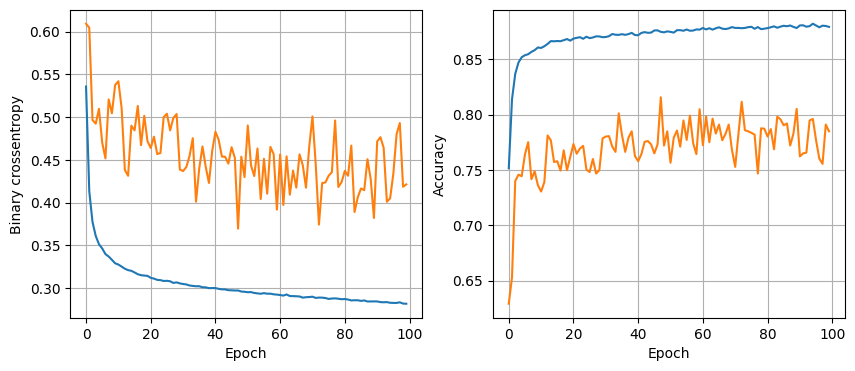

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 540us/step - accuracy: 0.8691 - loss: 0.3112
------------------------------------------------------------------------------------------
32 node, 0.2 dropout_prob, 0.1 lr, 32 batch_size


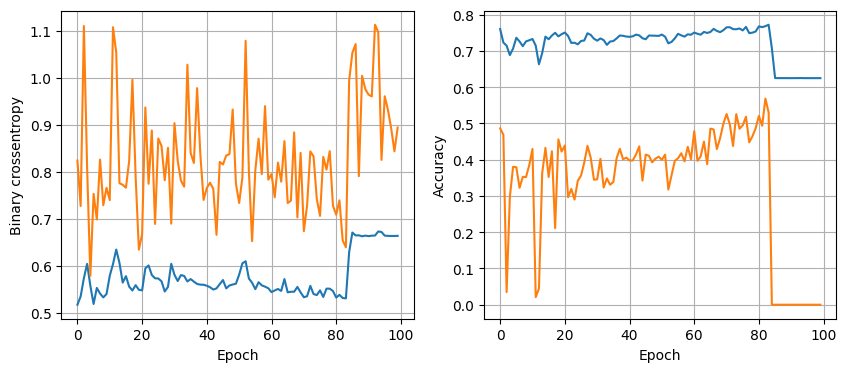

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 580us/step - accuracy: 0.6604 - loss: 0.6509
------------------------------------------------------------------------------------------
32 node, 0.2 dropout_prob, 0.1 lr, 64 batch_size


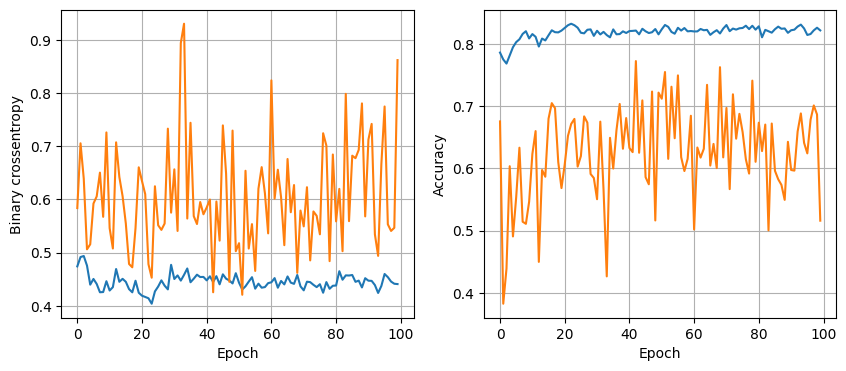

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 542us/step - accuracy: 0.8162 - loss: 0.4401
------------------------------------------------------------------------------------------
32 node, 0.2 dropout_prob, 0.1 lr, 128 batch_size


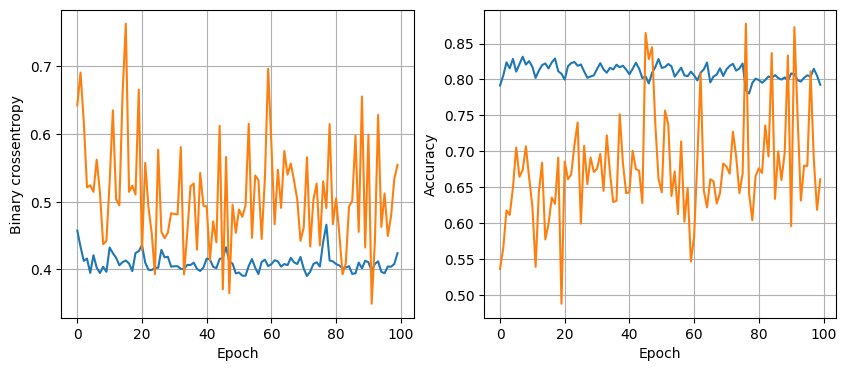

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 655us/step - accuracy: 0.8612 - loss: 0.3394
------------------------------------------------------------------------------------------
32 node, 0.2 dropout_prob, 0.005 lr, 32 batch_size


KeyboardInterrupt: 

In [32]:
least_val_loss = float('inf')
least_loss_model = None
epochs = 100

for num_nodes in [16, 32, 64]:
  for dropout_prob in [0, 0.2]:
    for lr in [0.1, 0.005, 0.001]:
      for batch_size in [32, 64, 128]:
        print("------------------------------------------------------------------------------------------")
        print(f"{num_nodes} node, {dropout_prob} dropout_prob, {lr} lr, {batch_size} batch_size")
        model, history = train_model(X_train, y_train, num_nodes, dropout_prob, lr, batch_size, epochs)
        plot_history(history)

        val_loss = model.evaluate(X_valid, y_valid)[0]
        if val_loss < least_val_loss:
          least_val_loss = val_loss
          least_loss_model = model
          


In [33]:
print(model.metrics_names)

['loss', 'compile_metrics']


In [ ]:
y_pred = least_loss_model.predict(X_test)
# + (y_pred > 0.5) -> make True/False
# + astype(int):
#   True -> 1
#   False -> 0
# + reshape(-1, ):
#  nếu y_pred.shape = (100, 1)
#  thí y_pred.reshape(-1, ) -> ép về  mảng 1 chiều: y_pred.shape = (100)
y_pred = (y_pred > 0.5).astype(int).reshape(-1, )
y_pred

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 360us/step


array([1, 1, 1, ..., 0, 1, 1], shape=(3804,))

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.77      0.82      1378
           1       0.88      0.93      0.91      2426

    accuracy                           0.88      3804
   macro avg       0.87      0.85      0.86      3804
weighted avg       0.87      0.88      0.87      3804

